In [8]:
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [9]:
network_list = [
    'conf','email_eu_modified','hospital','school','work'
]

In [31]:
network_name = network_list[4]
complex_c = pd.read_csv(f'../results/weighted/given_th_n=300/weighted_complex_{network_name}_EPH.csv')
simple_c = pd.read_csv(f'../results/weighted/given_betha_n=300/weighted_simple_{network_name}_EPH.csv')

In [32]:
print(network_name)

work


In [33]:
complex_c[['EPH','corr']].corr()
simple_c[['EPH','corr']].corr()

,EPH,corr
EPH,1.000000,0.066068
corr,0.066068,1.000000


In [34]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize

# Prepare the data
X_complex = complex_c[['corr', 'EPH']]
y_complex = np.ones(len(complex_c))
X_simple = simple_c[['corr', 'EPH']]
y_simple = np.zeros(len(simple_c))

X = pd.concat([X_complex, X_simple])
y = np.concatenate([y_complex, y_simple])

# Initialize lists to store results
thetas = np.sort(complex_c['theta'].unique())
betas = np.sort(simple_c['betha'].unique())
auc_roc_corr = np.zeros((len(thetas), len(betas)))
auc_roc_eph = np.zeros((len(thetas), len(betas)))

# Perform classification for each combination of theta and beta
for i, theta in enumerate(thetas):
    for j, beta in enumerate(betas):
        # Filter data based on current theta and beta
        mask_complex = complex_c['theta'] == theta
        mask_simple = simple_c['betha'] == beta
        
        X_filtered = pd.concat([X_complex[mask_complex], X_simple[mask_simple]])
        y_filtered = np.concatenate([y_complex[mask_complex], y_simple[mask_simple]])
        
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.3, random_state=42)
        
        # Train and evaluate classifier using 'corr' feature
        clf_corr = DecisionTreeClassifier(random_state=42)
        clf_corr.fit(X_train[['corr']], y_train)
        y_pred_proba_corr = clf_corr.predict_proba(X_test[['corr']])[:, 1]
        auc_roc_corr[i, j] = roc_auc_score(y_test, y_pred_proba_corr)
        
        # Train and evaluate classifier using 'EPH' feature
        clf_eph = DecisionTreeClassifier(random_state=42)
        clf_eph.fit(X_train[['EPH']], y_train)
        y_pred_proba_eph = clf_eph.predict_proba(X_test[['EPH']])[:, 1]
        auc_roc_eph[i, j] = roc_auc_score(y_test, y_pred_proba_eph)


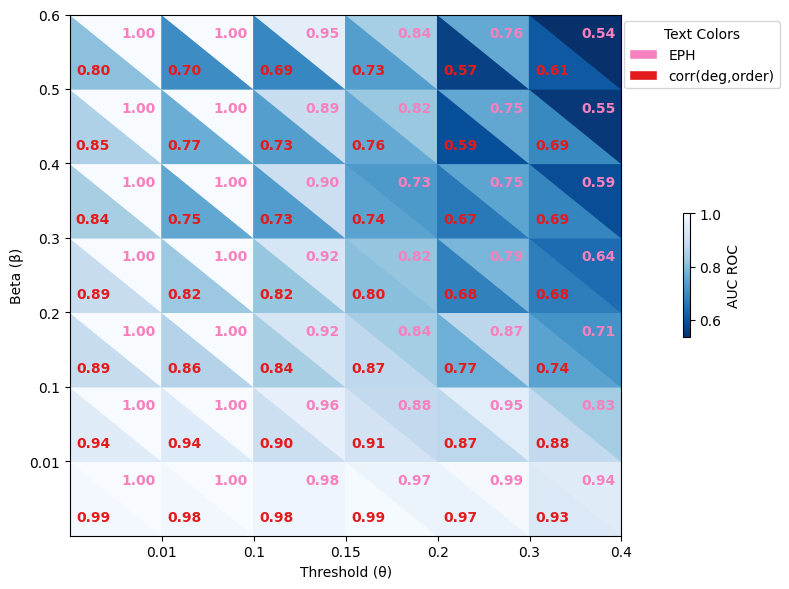

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 6))

# Define a common color range for both plots
vmin = min(auc_roc_corr.min(), auc_roc_eph.min())
vmax = max(auc_roc_corr.max(), auc_roc_eph.max())

# Function to draw a split cell (two triangles) and display text in each triangle
def split_cell(ax, data1, data2, xlabels, ylabels, vmin, vmax, cmap1, cmap2):
    for i in range(len(xlabels)):
        for j in range(len(ylabels)):
            # Get color for the first half (corr)
            color1 = cmap1((data1[j, i] - vmin) / (vmax - vmin))
            # Get color for the second half (EPH)
            color2 = cmap2((data2[j, i] - vmin) / (vmax - vmin))
            
            # Draw the top-left triangle (corr feature)
            triangle1 = Polygon([(i, j), (i+1, j), (i, j+1)], color=color1)
            ax.add_patch(triangle1)
            
            # Draw the bottom-right triangle (EPH feature)
            triangle2 = Polygon([(i+1, j+1), (i+1, j), (i, j+1)], color=color2)
            ax.add_patch(triangle2)
            
            # Add text in the center of the top-left triangle (corr value)
            ax.text(i + 0.25, j + 0.25, f'{data1[j, i]:.2f}', ha='center', va='center', fontsize=10, color='#e41a1c', fontweight='bold')
            
            # Add text in the center of the bottom-right triangle (EPH value)
            ax.text(i + 0.75, j + 0.75, f'{data2[j, i]:.2f}', ha='center', va='center', fontsize=10, color='#f781bf', fontweight='bold')

# Create colormaps
cmap_corr = plt.get_cmap('Blues_r')
cmap_eph = plt.get_cmap('Blues_r')

# Call the function to split each cell and plot the triangles
split_cell(ax, auc_roc_corr.T, auc_roc_eph.T, thetas, betas, vmin, vmax, cmap_corr, cmap_eph)

# Set labels and title
ax.set_xticks(np.arange(len(thetas)) + 1)  # Shift tick positions by 0.5 to center
ax.set_yticks(np.arange(len(betas)) + 1)   # Shift tick positions by 0.5 to center
ax.set_xticklabels(thetas)
ax.set_yticklabels(betas)
ax.set_xlabel('Threshold (θ)')
ax.set_ylabel('Beta (β)')

# Add colorbars for both colormaps
sm_corr = plt.cm.ScalarMappable(cmap=cmap_corr, norm=plt.Normalize(vmin=vmin, vmax=vmax))

# Adjust colorbars
cbar_corr = fig.colorbar(sm_corr, ax=ax, fraction=0.01, pad=0.1)
cbar_corr.set_label('AUC ROC')

# Create a custom legend for the text colors
legend_elements = [
    Patch(facecolor='#f781bf', edgecolor='w', label='EPH'),
    Patch(facecolor='#e41a1c', edgecolor='w', label='corr(deg,order)')
]

# Combine the heatmap legend and text color legend together
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1.0), title="Text Colors")

# Adjust the layout to make room for both legends
plt.subplots_adjust(right=0.9)

# Save the plot as a vectorized PDF
plt.tight_layout()
plt.savefig(f"../results/weighted_plots/n=300_heatmap/heatmap_{network_name}_acc_th_be.pdf", format='pdf')  # Save as PDF

plt.show()
